# Figure 3 — Spatial error reduction

Maps of CTRL RMSE minus ML RMSE.


## 1. Load only the required common-grid data


In [13]:
from pathlib import Path
import importlib
import sys
import numpy as np
import pandas as pd
import xarray as xr
import dask

PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / 'src').exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
if not (PROJECT_ROOT / 'src').exists():
    raise RuntimeError('Run from ml_implement_paper/ or its notebooks/ directory')
sys.path.insert(0, str(PROJECT_ROOT))

from src import io as data_io
from src import metrics, plotting, preprocessing, spatial_cache
spatial_cache = importlib.reload(spatial_cache)
plotting = importlib.reload(plotting)

config = data_io.load_config(PROJECT_ROOT / 'config' / 'paths.yaml')
analysis = config['analysis']

# ------------------------- User-adjustable settings -------------------------
OUTPUT_ROOT = Path('/global/cfs/cdirs/e3sm/www/zhan391/sea_crogs/online_diag')
ML_ROOT = Path('/pscratch/sd/z/zhan391/seacrogs_scratch/ml_method_2026')
REFERENCE_ROOT = Path('/pscratch/sd/z/zhan391/seacrogs_scratch/reference_nudge')
POST_SUBDIR = Path('post/atm/180x360_aave/ts/3hourly/1yr')
PERIOD = '201201_201212'
FORCE_COMPUTE = False  # True: recompute every selected case/variable pair.
REUSE_LEGACY_CACHES = True  # Split existing case caches without rereading raw data.
# Legacy files lack complete provenance; disable reuse if their settings differed.
DASK_WORKERS = 4
REQUIRED_VARIABLES = ['T500', 'U200', 'U850', 'TMQ', 'PRECT']
CASE_DIRS = {
    'CTRL': ML_ROOT / 'F20TR_NE30PG2_EC30TO60E2R2_CTRL',
    'UNET-IMT': ML_ROOT / 'F20TR_NE30PG2_EC30TO60E2R2_UVTQ_UNET_IMT_NS6_WOQMADJ_WOTVCON_PBL222_WOVSMOOTH',
    'UNETXTR-IMT': ML_ROOT / 'F20TR_NE30PG2_EC30TO60E2R2_UVTQ_UNETXTR_IMT_NS6_WOQMADJ_WOTVCON_PBL222_WOVSMOOTH',
    'UNETXTR-IMT-A15': ML_ROOT / 'F20TR_NE30PG2_EC30TO60E2R2_UVTQ_UNETXTR_IMT_NS6_WQMADJ_WTVCON_PBL222_WVSMOOTH-S0.15',
    'UNETXTR-IMT-C05': ML_ROOT / 'F20TR_NE30PG2_EC30TO60E2R2_UVTQ_UNETXTR_IMT_NS6_SCL0.5_WOQMADJ_WOTVCON_PBL222_WOVSMOOTH',
    'UNETXTR-IMT-C05A15': ML_ROOT / 'F20TR_NE30PG2_EC30TO60E2R2_UVTQ_UNETXTR_IMT_NS6_SCL0.5_WQMADJ_WTVCON_PBL222_WVSMOOTH-S0.15',
    'UNETXTR-LCZ-C05A15': ML_ROOT / 'F20TR_NE30PG2_EC30TO60E2R2_UVTQ_UNETXTR_LANCZOS_NS6_SCL0.5_WQMADJ_WTVCON_PBL222_WVSMOOTH-S0.15',
    'UNETXTR-LCZ-C05A15-PTAP100': ML_ROOT / 'F20TR_NE30PG2_EC30TO60E2R2_UVTQ_UNETXTR_LANCZOS_NS6_SCL0.5_PTAPUNI100HPA_WQMADJ_WTVCON_PBL222_WVSMOOTH-S0.15',
    'REF': REFERENCE_ROOT / 'F20TR_ne30pg2_EC30to60E2r2_NDGUVTQ_IMT_3hr_pm-cpu_08-01-25',
}
FONT_SIZE = 12
FIGURE_SIZE = (24, 16)
COLOR_MAP = 'RdBu_r'
PLOT_FIELD = 'improvement_percent'
MAP_PROJECTION = 'platecarree'
LONGITUDE_TICKS = [-180, -120, -60, 0, 60, 120, 180]
LATITUDE_TICKS = [-90, -60, -30, 0, 30, 60, 90]
COLOR_LEVELS = [-100, -50, -25, -10, -5, 0, 5, 10, 25, 50, 100]
COLORBAR_LABEL = 'RMSE improvement relative to CTRL [%]'
FIGURE_TITLE = 'Spatial RMSE improvement relative to CTRL (positive is better)'
COASTLINE_LINEWIDTH = 0.5
# ---------------------------------------------------------------------------

paths = {
    'processed': OUTPUT_ROOT / 'processed',
    'figures': OUTPUT_ROOT / 'figures',
    'tables': OUTPUT_ROOT / 'tables',
}
for output_dir in paths.values():
    output_dir.mkdir(parents=True, exist_ok=True)
DIAGNOSTIC_DIR = paths['processed'] / 'spatial_error_reduction'
DIAGNOSTIC_DIR.mkdir(parents=True, exist_ok=True)

ML_CASES = tuple(name for name in CASE_DIRS if name not in {'CTRL', 'REF'})
if not {'CTRL', 'REF'}.issubset(CASE_DIRS):
    raise ValueError('CASE_DIRS must include CTRL and REF')
if not ML_CASES:
    raise ValueError('Select at least one ML case in CASE_DIRS')
# Legacy combined files remain untouched. New checkpoints are independent.
LEGACY_PATHS = {name: DIAGNOSTIC_DIR / f'{name}_{PERIOD}.nc' for name in ML_CASES}
VARIABLE_DIR = DIAGNOSTIC_DIR / 'by_variable'
PAIR_PATHS = {
    (name, variable): VARIABLE_DIR / name / f'{variable}_{PERIOD}.nc'
    for name in ML_CASES for variable in REQUIRED_VARIABLES
}

def pair_signature(name, variable):
    return spatial_cache.signature(name, variable, CASE_DIRS, POST_SUBDIR, PERIOD, analysis)

def pair_source(name, variable):
    if FORCE_COMPUTE:
        return 'compute'
    if spatial_cache.cache_valid(PAIR_PATHS[name, variable], name, variable, pair_signature(name, variable)):
        return 'cached'
    # An incompatible new checkpoint must not be replaced by an older legacy one.
    if (REUSE_LEGACY_CACHES and not PAIR_PATHS[name, variable].exists()
            and spatial_cache.legacy_valid(LEGACY_PATHS[name], name, variable, CASE_DIRS, PERIOD, analysis)):
        return 'legacy'
    return 'compute'

PAIR_SOURCES = {pair: pair_source(*pair) for pair in PAIR_PATHS}
PAIRS_TO_COMPUTE = tuple(pair for pair, source in PAIR_SOURCES.items() if source == 'compute')
RECOMPUTE = bool(PAIRS_TO_COMPUTE)
status = {source: [f'{name}:{variable}' for (name, variable), mode in PAIR_SOURCES.items() if mode == source]
          for source in ('cached', 'legacy', 'compute')}
status


{'cached': ['UNET-IMT:T500',
  'UNET-IMT:U200',
  'UNET-IMT:U850',
  'UNET-IMT:TMQ',
  'UNET-IMT:PRECT',
  'UNETXTR-IMT:T500',
  'UNETXTR-IMT:U200',
  'UNETXTR-IMT:U850',
  'UNETXTR-IMT:TMQ',
  'UNETXTR-IMT:PRECT',
  'UNETXTR-IMT-A15:T500',
  'UNETXTR-IMT-A15:U200',
  'UNETXTR-IMT-A15:U850',
  'UNETXTR-IMT-A15:TMQ',
  'UNETXTR-IMT-A15:PRECT',
  'UNETXTR-IMT-C05:T500',
  'UNETXTR-IMT-C05:U200',
  'UNETXTR-IMT-C05:U850',
  'UNETXTR-IMT-C05:TMQ',
  'UNETXTR-IMT-C05:PRECT',
  'UNETXTR-IMT-C05A15:T500',
  'UNETXTR-IMT-C05A15:U200',
  'UNETXTR-IMT-C05A15:U850',
  'UNETXTR-IMT-C05A15:TMQ',
  'UNETXTR-IMT-C05A15:PRECT',
  'UNETXTR-LCZ-C05A15:T500',
  'UNETXTR-LCZ-C05A15:U200',
  'UNETXTR-LCZ-C05A15:U850',
  'UNETXTR-LCZ-C05A15:TMQ',
  'UNETXTR-LCZ-C05A15:PRECT',
  'UNETXTR-LCZ-C05A15-PTAP100:T500',
  'UNETXTR-LCZ-C05A15-PTAP100:U200',
  'UNETXTR-LCZ-C05A15-PTAP100:U850',
  'UNETXTR-LCZ-C05A15-PTAP100:TMQ',
  'UNETXTR-LCZ-C05A15-PTAP100:PRECT'],
 'legacy': [],
 'compute': []}

## 2. Check required inputs

Only uncached case/variable pairs need raw inputs. Finite-value QC runs during
loading in block 3, avoiding a separate full-data pass.


In [14]:
input_pairs = set()
for name, variable in PAIRS_TO_COMPUTE:
    input_pairs.update((case, variable) for case in ('CTRL', 'REF', name))
missing = [str(CASE_DIRS[case] / POST_SUBDIR / f'{variable}_{PERIOD}.nc')
           for case, variable in sorted(input_pairs)
           if not (CASE_DIRS[case] / POST_SUBDIR / f'{variable}_{PERIOD}.nc').exists()]
if missing:
    raise FileNotFoundError('Missing inputs for uncached variables:\n' + '\n'.join(missing))
print(f'{len(PAIRS_TO_COMPUTE)} case/variable pairs need computation; '
      f'{sum(mode == "legacy" for mode in PAIR_SOURCES.values())} can be copied from existing caches.')


0 case/variable pairs need computation; 0 can be copied from existing caches.


## 3. Compute and immediately save each case/variable

Each completed pair is saved atomically. Rerunning this block rechecks checkpoints
and skips completed pairs (`FORCE_COMPUTE=False`). CTRL and REF are loaded once
per missing variable and reused across its pending cases.


In [15]:
from time import perf_counter

started = perf_counter()
qc = {}
# Refresh here too, allowing direct resume after an interrupted block.
PAIR_SOURCES = {pair: pair_source(*pair) for pair in PAIR_PATHS}
for (name, variable), source in PAIR_SOURCES.items():
    if source == 'legacy':
        with xr.open_dataset(LEGACY_PATHS[name]) as old:
            product = old.sel(experiment=[name], variable=[variable]).load()
        product.attrs.update(cache_signature=pair_signature(name, variable),
                             migrated_from=str(LEGACY_PATHS[name]))
        spatial_cache.save_atomic(product, PAIR_PATHS[name, variable])
        print(f'Reused existing cache: {name}:{variable}', flush=True)

def load_daily_field(case, variable, expected_time=None, expected_grid=None):
    path = CASE_DIRS[case] / POST_SUBDIR / f'{variable}_{PERIOD}.nc'
    print(f'Loading {case}:{variable}', flush=True)
    with xr.open_dataset(path, chunks={'time': 32, 'lat': 45, 'lon': 90}, cache=False) as raw:
        selected = preprocessing.subset_time(raw[[variable]], analysis['start_date'], analysis['end_date'])
        time_index = selected.indexes['time']
        if len(time_index) == 0 or not time_index.is_unique or not time_index.is_monotonic_increasing:
            raise ValueError(f'{case}:{variable}: empty, duplicated, or unsorted timestamps')
        if expected_time is not None and not time_index.equals(expected_time):
            raise ValueError(f'{case}:{variable}: timestamps differ from REF; align inputs before caching')
        if expected_grid is not None:
            for coordinate in ('lat', 'lon'):
                if not selected[coordinate].equals(expected_grid[coordinate]):
                    raise ValueError(f'{case}:{variable}: {coordinate} grid differs from REF')
        field = preprocessing.daily_mean(selected)[variable].compute(
            scheduler='threads', num_workers=DASK_WORKERS,
        )
    finite = np.isfinite(field.values)
    if not finite.any():
        raise ValueError(f'{case}:{variable} contains no finite values')
    qc.setdefault(case, {})[variable] = int((~finite).sum())
    return field, time_index

for variable in REQUIRED_VARIABLES:
    pending = [name for name in ML_CASES if PAIR_SOURCES[name, variable] == 'compute']
    if not pending:
        continue
    reference, reference_time = load_daily_field('REF', variable)
    control_field, _ = load_daily_field('CTRL', variable, reference_time, reference)
    control = metrics.spatial_rmse(control_field, reference)
    del control_field
    sample = reference.isel(time=0, drop=True)
    area = np.cos(np.deg2rad(sample.lat)).clip(min=0).broadcast_like(sample)
    area = area / area.sum()
    for name in pending:
        case_started = perf_counter()
        model, _ = load_daily_field(name, variable, reference_time, reference)
        product = spatial_cache.calculate(model, reference, control, area, analysis['minimum_control_rmse'])
        product = product.expand_dims(experiment=[name], variable=[variable])
        product.attrs.update({
            'cache_signature': pair_signature(name, variable),
            'experiment': name, 'period': PERIOD,
            'control_case': str(CASE_DIRS['CTRL']), 'reference_case': str(CASE_DIRS['REF']),
            'global_rmse_definition': 'Mean daily area-weighted RMSE versus REF',
            'global_pcc_definition': 'Area-weighted mean grid-cell temporal Pearson correlation versus REF',
            'grid_fraction_definition': 'Unweighted percent of valid global grid cells with CTRL minus ML RMSE above/below zero',
        })
        spatial_cache.save_atomic(product, PAIR_PATHS[name, variable])
        del model, product
        print(f'Saved {name}:{variable} in {perf_counter() - case_started:.1f}s -> '
              f'{PAIR_PATHS[name, variable]}', flush=True)
    del reference, control

print(f'Finished in {(perf_counter() - started) / 60:.1f} min')
diagnostic = spatial_cache.load_products(PAIR_PATHS, ML_CASES, REQUIRED_VARIABLES)
diagnostic


Finished in 0.0 min


<xarray.Dataset> Size: 18MB
Dimensions:                  (experiment: 7, variable: 5, lat: 180, lon: 360,
                              region: 4)
Coordinates:
  * experiment               (experiment) <U26 728B 'UNET-IMT' ... 'UNETXTR-L...
  * variable                 (variable) <U5 100B 'T500' 'U200' ... 'TMQ' 'PRECT'
  * lat                      (lat) float64 1kB -89.5 -88.5 -87.5 ... 88.5 89.5
  * lon                      (lon) float64 3kB 0.5 1.5 2.5 ... 357.5 358.5 359.5
  * region                   (region) <U15 240B 'Global' ... 'SH_extratropics'
Data variables:
    rmse_reduction           (experiment, variable, lat, lon) float32 9MB -1....
    improvement_percent      (experiment, variable, lat, lon) float32 9MB -47...
    regional_mean_reduction  (experiment, variable, region) float64 1kB -0.20...
    global_rmse              (experiment, variable) float64 280B 4.042 ... 8....
    global_pcc               (experiment, variable) float64 280B 0.4144 ... 0...
    improved_grid_fraction   (experiment, variable) float64 280B 36.5 ... 74.06
    degraded_grid_fraction   (experiment, variable) float64 280B 63.5 ... 25.94
Attributes:
    period:                    201201_201212
    control_case:              /pscratch/sd/z/zhan391/seacrogs_scratch/ml_met...
    reference_case:            /pscratch/sd/z/zhan391/seacrogs_scratch/refere...
    global_rmse_definition:    Mean daily area-weighted RMSE versus REF
    global_pcc_definition:     Area-weighted mean grid-cell temporal Pearson ...
    grid_fraction_definition:  Unweighted percent of valid global grid cells ...

## 4. Reload the diagnostic product and create the figure


Figure 3 summary saved to /global/cfs/cdirs/e3sm/www/zhan391/sea_crogs/online_diag/tables/fig03_regional_error_reduction.csv
Run Figure 1 first; missing RMSE caches:
  /global/cfs/cdirs/e3sm/www/zhan391/sea_crogs/online_diag/processed/global_rmse_timeseries/UNETXTR-LCZ-C05A15-PTAP100_201201_201212.nc


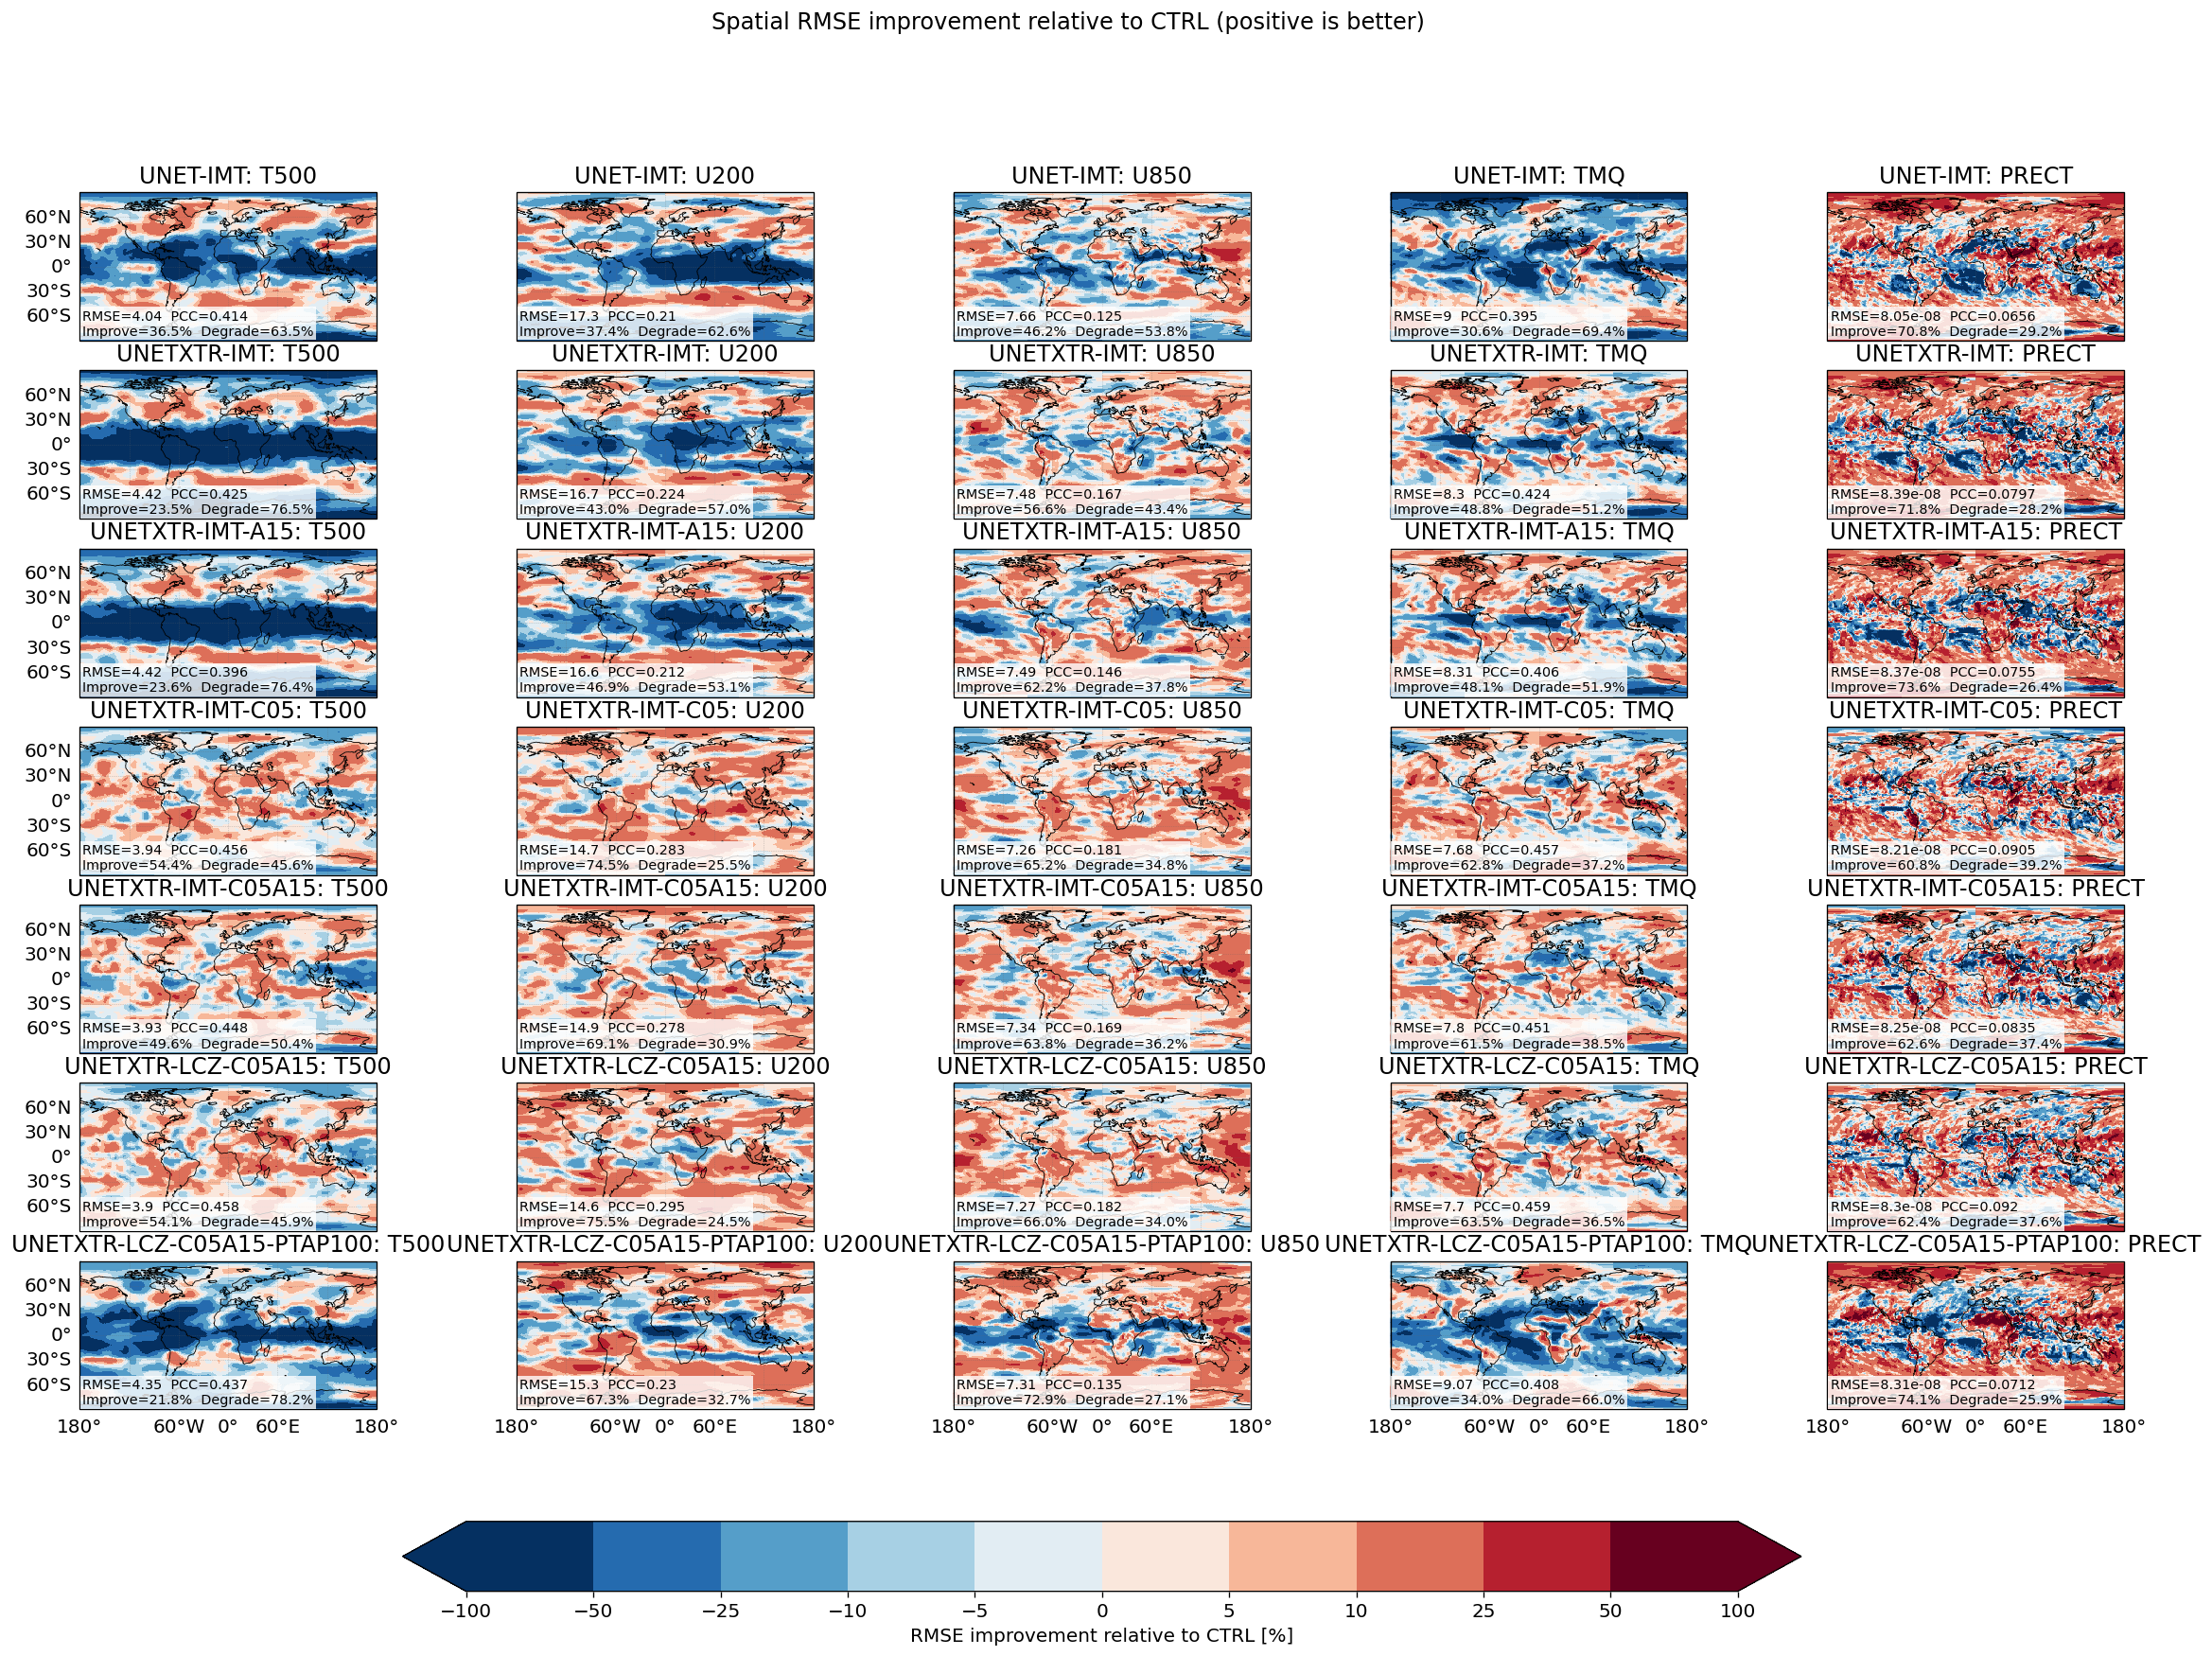

In [16]:
FIGURE_PATH = paths['figures'] / 'fig03_error_reduction.png'
PLOT_VARIABLES = REQUIRED_VARIABLES
PLOT_OPTIONS = {
    'figsize': FIGURE_SIZE, 
    'cmap': COLOR_MAP,
    'data_variable': PLOT_FIELD,
    'map_projection': MAP_PROJECTION,
    'longitude_ticks': LONGITUDE_TICKS,
    'latitude_ticks': LATITUDE_TICKS,
    'color_levels': COLOR_LEVELS,
    'font_size': FONT_SIZE,
    'colorbar_label': COLORBAR_LABEL,
    'title': FIGURE_TITLE,
    'coastline_linewidth': COASTLINE_LINEWIDTH,
}
diagnostic = spatial_cache.load_products(PAIR_PATHS, ML_CASES, REQUIRED_VARIABLES)
plotting.plot_spatial_error_reduction(diagnostic, PLOT_VARIABLES, FIGURE_PATH, **PLOT_OPTIONS)

regional_summary = diagnostic['regional_mean_reduction'].to_dataframe(name='regional_mean_rmse_reduction').reset_index()
regional_path = paths['tables'] / 'fig03_regional_error_reduction.csv'
regional_summary.to_csv(regional_path, index=False)
print(f'Figure 3 summary saved to {regional_path}')

# Build the cross-figure table only after Figure 1 has produced its cache.
rmse_dir = paths['processed'] / 'global_rmse_timeseries'
rmse_paths = {
    name: rmse_dir / f'{name}_{PERIOD}.nc' for name in ('CTRL', *ML_CASES)
}
if all(path.exists() for path in rmse_paths.values()):
    rmse_product = xr.concat(
        [xr.open_dataset(path) for path in rmse_paths.values()], dim='experiment'
    )
    rmse_summary = rmse_product['rmse'].mean('time').to_dataframe(name='mean_daily_rmse').reset_index()
    improvement_summary = rmse_product['improvement_percent'].mean('time').to_dataframe(name='mean_improvement_percent').reset_index()
    summary_path = paths['tables'] / 'summary_metrics.csv'
    pd.concat({
        'rmse': rmse_summary,
        'improvement': improvement_summary,
        'regional_reduction': regional_summary,
    }, names=['diagnostic']).to_csv(summary_path, index=True)
    print(f'Consolidated summary saved to {summary_path}')
else:
    missing_rmse = [str(path) for path in rmse_paths.values() if not path.exists()]
    print('Run Figure 1 first; missing RMSE caches:', *missing_rmse, sep='\n  ')